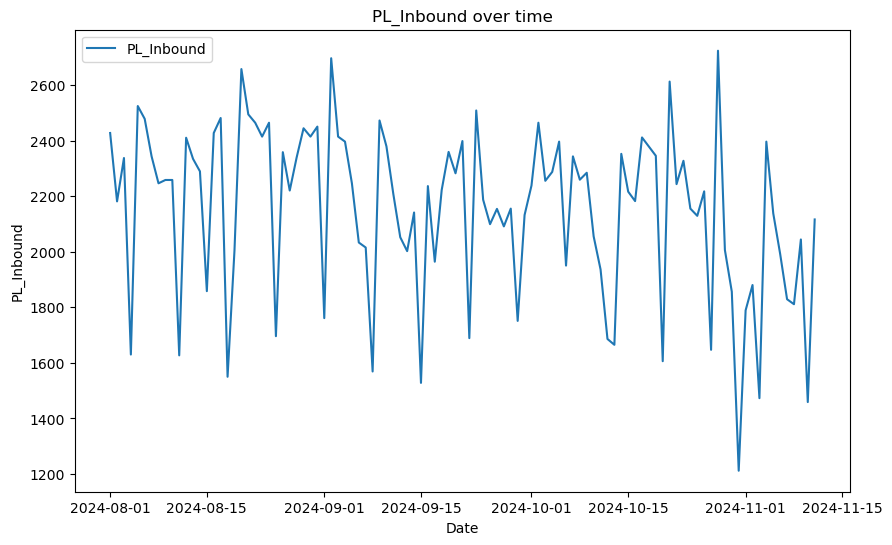

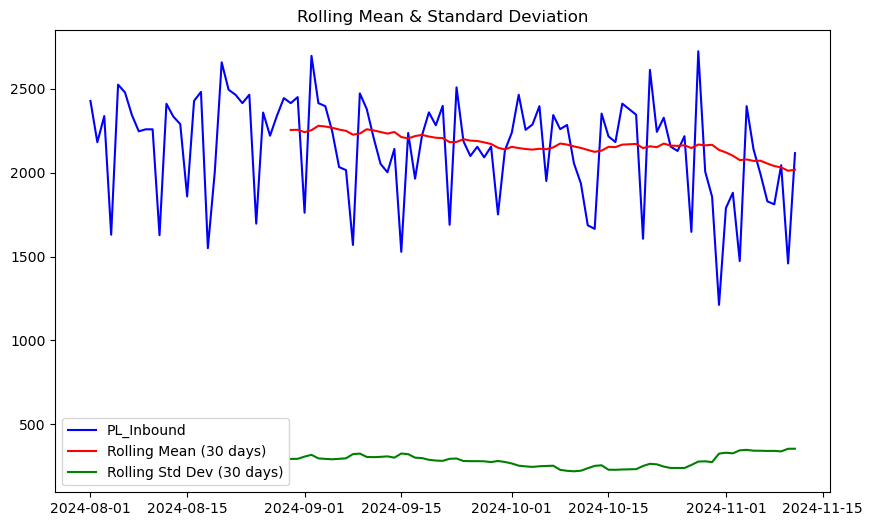

Results of Dickey-Fuller Test:
Test Statistic                 -2.103707
p-value                         0.243027
#Lags Used                      7.000000
Number of Observations Used    94.000000
Critical Value (1%)            -3.501912
Critical Value (5%)            -2.892815
Critical Value (10%)           -2.583454
dtype: float64


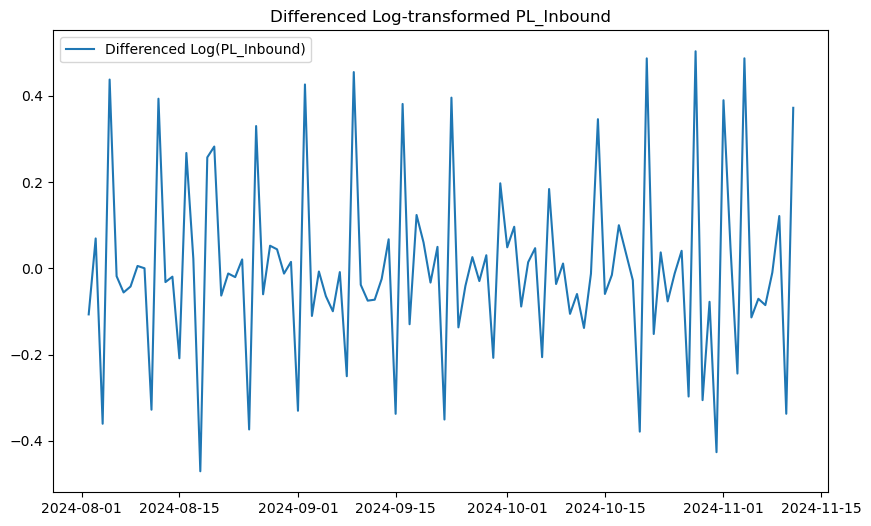

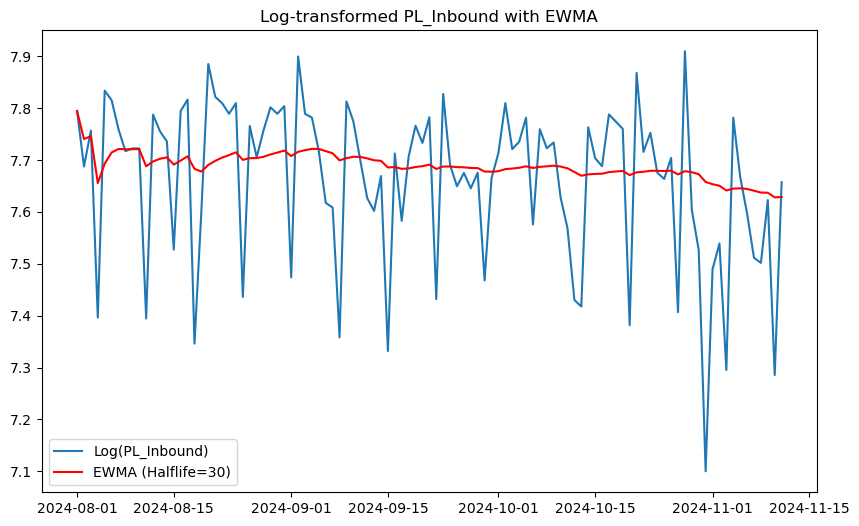

C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


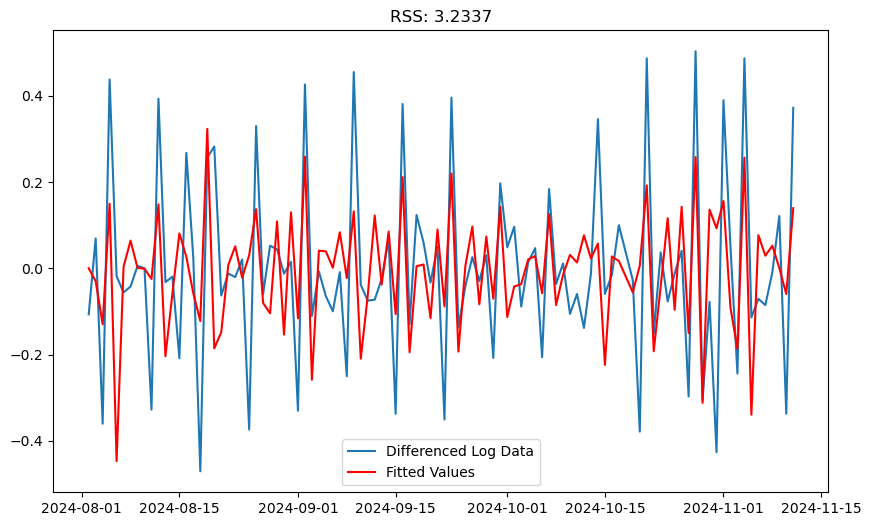

C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


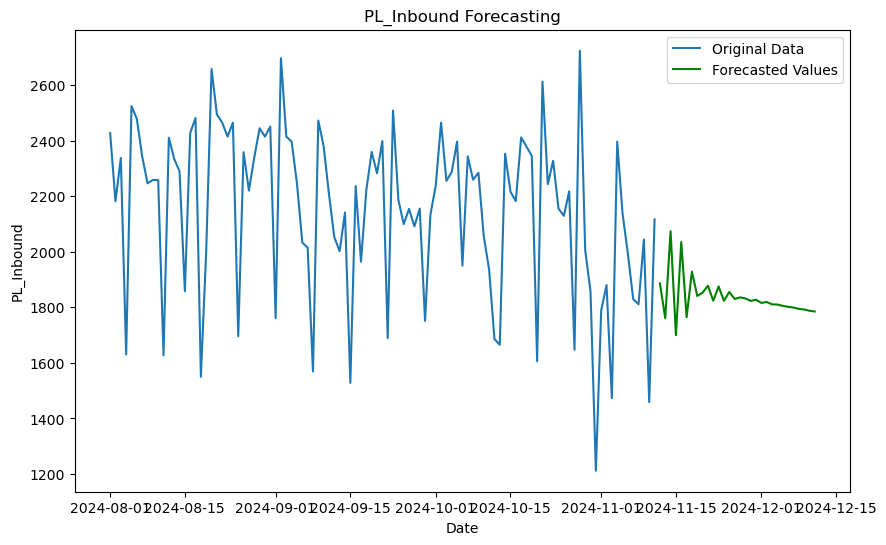

Forecasted values:
101    1886.043673
102    1761.236340
103    2073.335074
104    1699.865944
105    2034.538767
106    1764.103969
107    1928.341223
108    1840.751586
109    1852.481354
110    1877.583241
111    1823.594619
112    1874.996862
113    1823.208982
114    1855.068979
115    1829.904903
116    1835.593184
117    1831.917390
118    1822.894314
119    1827.302240
120    1815.711965
121    1818.900647
122    1810.664327
123    1809.822702
124    1805.367458
125    1801.604271
126    1799.076817
127    1794.373044
128    1792.059382
129    1787.664334
130    1784.817729
Name: predicted_mean, dtype: float64


In [15]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from matplotlib.pylab import rcParams

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
rcParams['figure.figsize'] = 10, 6


dataset = pd.read_excel(r'C:\Users\rajeshkumar.t\Desktop\BBD\CTU_Offered.xlsx')
dataset['Date'] = pd.to_datetime(dataset['Date'], infer_datetime_format=True)
dataset.set_index('Date', inplace=True)
dataset.index.freq = 'D'  # Set frequency to daily (change if needed)


dataset['PL_Inbound'].replace([np.inf, -np.inf], np.nan, inplace=True)
indexedDataset = dataset.dropna()


plt.plot(indexedDataset["PL_Inbound"], label="PL_Inbound")
plt.xlabel("Date")
plt.ylabel("PL_Inbound")
plt.title("PL_Inbound over time")
plt.legend()
plt.show()


rolmean = indexedDataset["PL_Inbound"].rolling(window=30).mean()
rolstd = indexedDataset["PL_Inbound"].rolling(window=30).std()


plt.plot(indexedDataset["PL_Inbound"], color="blue", label="PL_Inbound")
plt.plot(rolmean, color="red", label="Rolling Mean (30 days)")
plt.plot(rolstd, color="green", label="Rolling Std Dev (30 days)")
plt.legend(loc='best')
plt.title("Rolling Mean & Standard Deviation")
plt.show()


print("Results of Dickey-Fuller Test:")
dftest = adfuller(indexedDataset["PL_Inbound"], autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key, value in dftest[4].items():
    dfoutput[f"Critical Value ({key})"] = value
print(dfoutput)

# Log transformation and differencing for stationarity
indexedDataset_logScale = np.log(indexedDataset['PL_Inbound'])
datasetLogScaleMinusMovingAverage = indexedDataset_logScale.diff().dropna()

# Plot differenced log-transformed data
plt.plot(datasetLogScaleMinusMovingAverage, label="Differenced Log(PL_Inbound)")
plt.title("Differenced Log-transformed PL_Inbound")
plt.legend()
plt.show()

# EWMA for smoothing visualization (optional)
exponentialDecayWeightedAverage = indexedDataset_logScale.ewm(halflife=30, min_periods=0, adjust=True).mean()
plt.plot(indexedDataset_logScale, label="Log(PL_Inbound)")
plt.plot(exponentialDecayWeightedAverage, color="red", label="EWMA (Halflife=30)")
plt.title("Log-transformed PL_Inbound with EWMA")
plt.legend(loc='best')
plt.show()

# ARIMA model fitting
model = ARIMA(datasetLogScaleMinusMovingAverage, order=(2, 1, 2), enforce_stationarity=False, enforce_invertibility=False)
results_AR = model.fit()

# Plot fitted values
plt.plot(datasetLogScaleMinusMovingAverage, label="Differenced Log Data")
plt.plot(results_AR.fittedvalues, color="red", label="Fitted Values")
plt.title('RSS: %.4f' % sum((results_AR.fittedvalues - datasetLogScaleMinusMovingAverage) ** 2))
plt.legend()
plt.show()

# Forecast
forecast_steps = 30
forecast_log_diff = results_AR.forecast(steps=forecast_steps)

# Convert forecasted differenced values back to the original scale
forecast_log = forecast_log_diff.cumsum() + indexedDataset_logScale.iloc[-1]
forecast = np.exp(forecast_log)

# Date range for forecasted values
forecast_dates = pd.date_range(start=indexedDataset.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')

# Plot original and forecasted values
plt.plot(indexedDataset["PL_Inbound"], label="Original Data")
plt.plot(forecast_dates, forecast, color="green", label="Forecasted Values")
plt.title("PL_Inbound Forecasting")
plt.xlabel("Date")
plt.ylabel("PL_Inbound")
plt.legend()
plt.show()


print(f"Forecasted values:\n{forecast}")
